<a href="https://colab.research.google.com/github/OnwutaKelvin/ML-notebooks/blob/main/Car_Pred_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#loading the data
df = pandas.read_csv('/content/Car details v3.csv')

In [ ]:
#show Sample of data
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
#Show shape of data
df.shape

(8128, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
#Check null values
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [ ]:
#Describe Numeric Data
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [ ]:
#Delete Nulls
df.dropna(inplace=True, ignore_index=True)  #ignore_index = Resets the index after dropping rows

In [ ]:
#Data after deleting nulls
df.sample(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
2030,Mahindra XUV500 W10 2WD,2015,1100000,110000,Diesel,Individual,Manual,First Owner,16.0 kmpl,2179 CC,140 bhp,330Nm@ 1600-2800rpm,7.0
3828,Maruti Swift VXI Optional,2015,550000,25000,Petrol,Individual,Manual,First Owner,20.4 kmpl,1197 CC,81.80 bhp,113Nm@ 4200rpm,5.0
923,Maruti Zen D,2003,85000,120000,Diesel,Individual,Manual,Third Owner,20.8 kmpl,1527 CC,58 bhp,789Nm@ 2250rpm,5.0
736,Maruti Vitara Brezza ZDi Plus Dual Tone,2016,700000,110000,Diesel,Individual,Manual,Second Owner,24.3 kmpl,1248 CC,88.5 bhp,200Nm@ 1750rpm,5.0
6882,Maruti Ertiga VDI,2015,549000,90000,Diesel,Individual,Manual,First Owner,20.77 kmpl,1248 CC,88.76 bhp,200Nm@ 1750rpm,7.0


In [ ]:
#The New of shape data
df.shape

(7906, 13)

Exploratory Data Analysis

what are the top 20 most frequent car brands in the dataset

<function matplotlib.pyplot.show(close=None, block=None)>

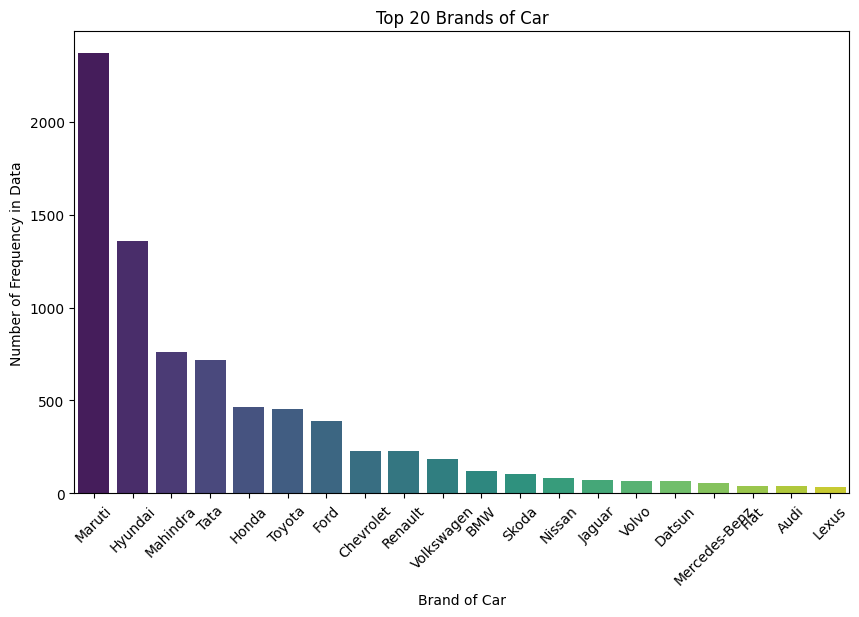

In [ ]:
#Extracting brand names
df['name'] = df['name'].str.split().str[0]

#Counting top 20 brands
brand_counts = df['name'].value_counts().nlargest(20)

#plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Brand of Car")
plt.ylabel("Number of Frequency in Data")
plt.title("Top 20 Brands of Car")
plt.show

How has the total selling price of cars changed over the years

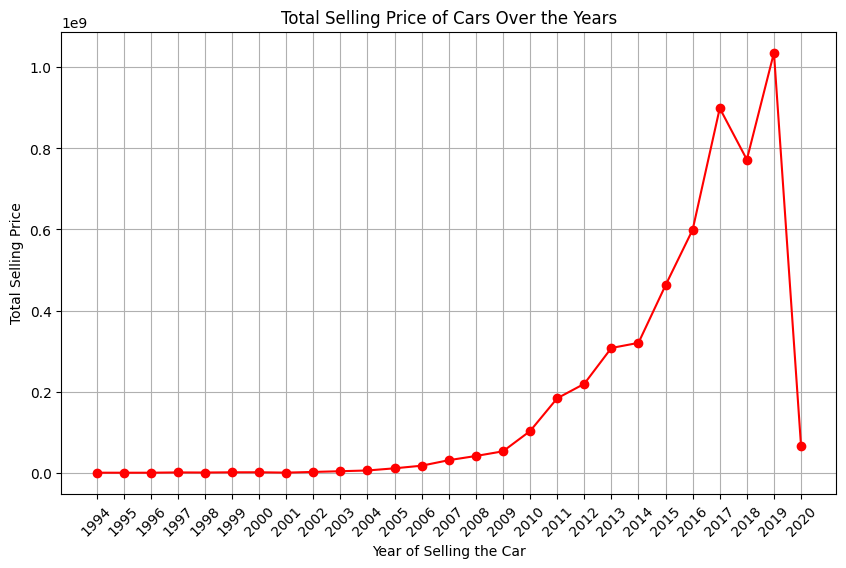

In [ ]:
#Summing selling price by year
sum_price_years = df.groupby('year')['selling_price'].sum()

#plotting
plt.figure(figsize=(10, 6))
plt.plot(sum_price_years.index, sum_price_years.values, marker='o', linestyle='-', color='red')
plt.xlabel("Year of Selling the Car")
plt.ylabel("Total Selling Price")
plt.title("Total Selling Price of Cars Over the Years")
plt.grid(True)
plt.xticks(sum_price_years.index.astype(int), rotation=45)
plt.show()

How does the type of fuel affect the average selling price of cars?

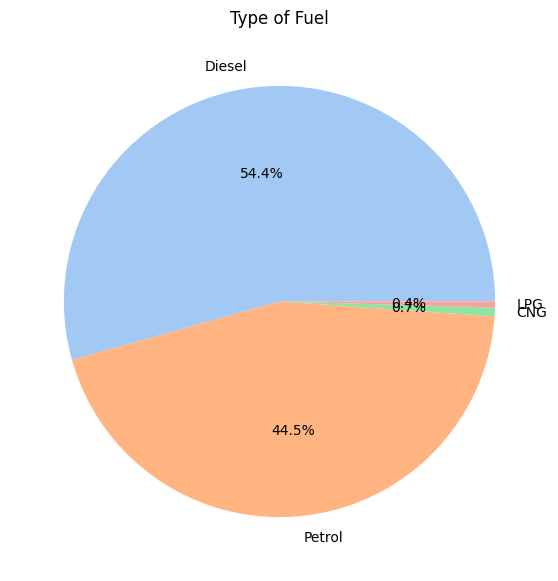

In [ ]:
#Pie chart for fuel types
type_of_fuel = df['fuel'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(type_of_fuel.values, labels=type_of_fuel.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Type of Fuel")
plt.show()

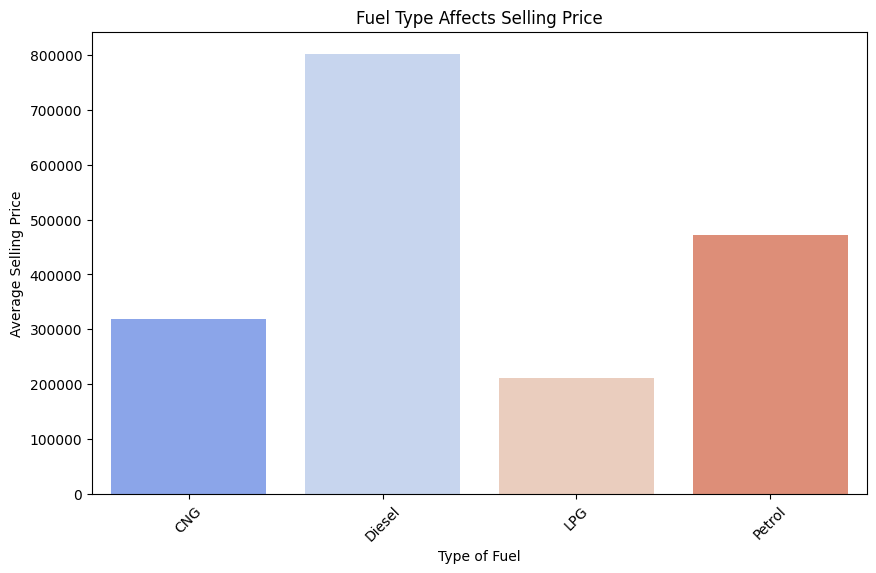

In [ ]:
#Bar chart for average selling price by fuel type
price_type_fuel = df.groupby('fuel')['selling_price'].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=price_type_fuel.index, y=price_type_fuel.values, palette='coolwarm')
plt.xlabel("Type of Fuel")
plt.ylabel("Average Selling Price")
plt.title("Fuel Type Affects Selling Price")
plt.xticks(rotation=45)
plt.show()

How does the type of transmission affect the average selling price of cars?

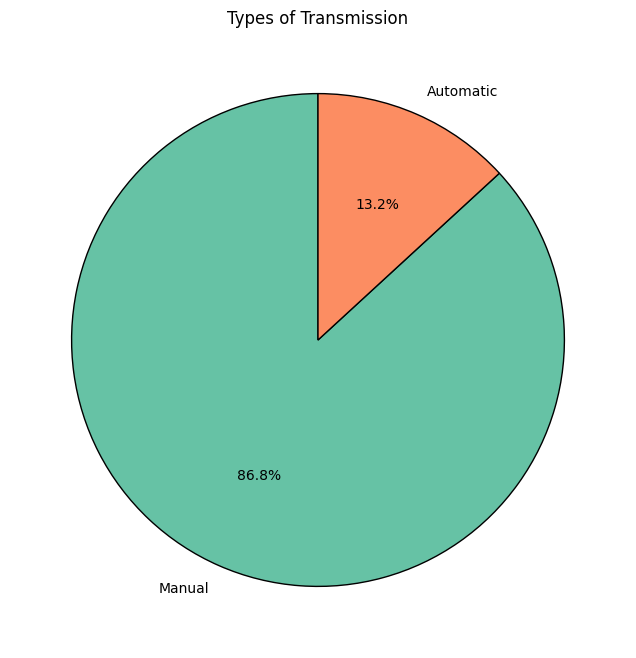

In [ ]:
#Pie chart for transmission types
type_transmission = df['transmission'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(type_transmission.values, labels=type_transmission.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=90, wedgeprops={'edgecolor':'black'})
plt.title("Types of Transmission")
plt.show()

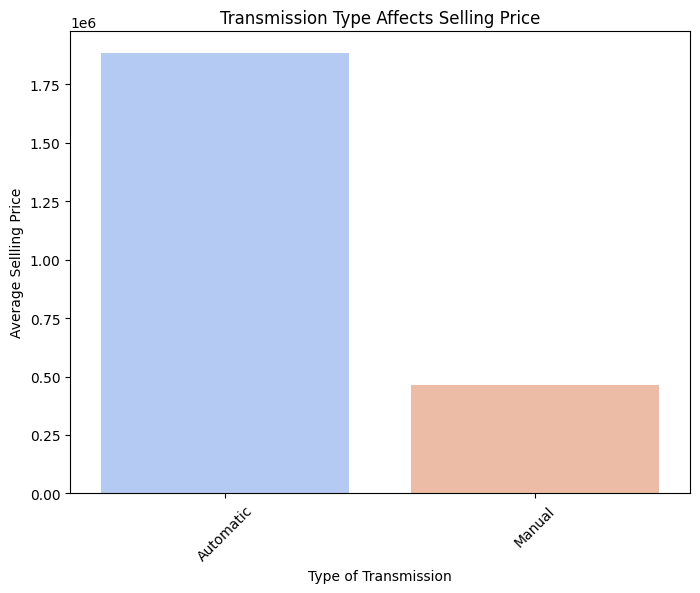

In [ ]:
#Bar chart for average selling price by transmission type
selling_price_transmission = df.groupby('transmission')['selling_price'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=selling_price_transmission.index, y=selling_price_transmission.values, palette='coolwarm')
plt.xlabel("Type of Transmission")
plt.ylabel("Average Sellling Price")
plt.title("Transmission Type Affects Selling Price")
plt.xticks(rotation=45)
plt.show()

How does the type of seller affect the average selling price of cars?

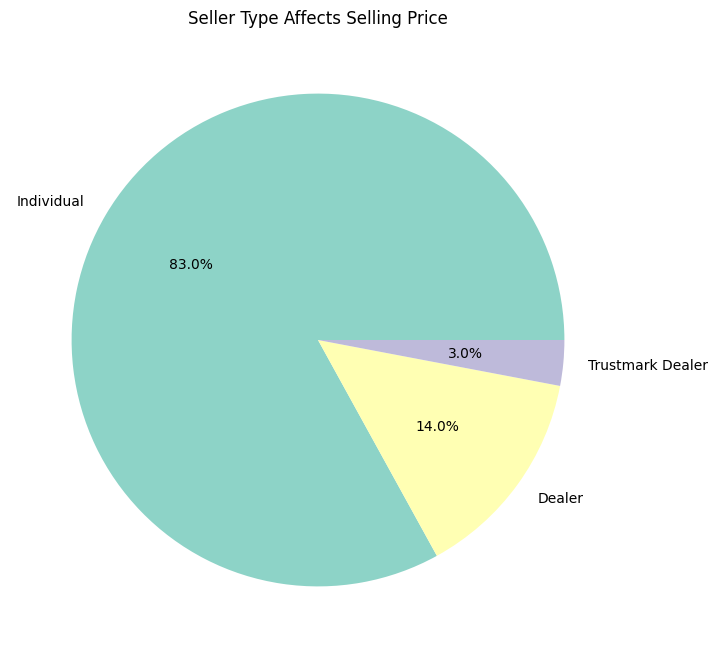

In [ ]:
#Pie chart for seller types
seller_types = df['seller_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(seller_types.values, labels=seller_types.index, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
plt.title("Seller Type Affects Selling Price")
plt.show()

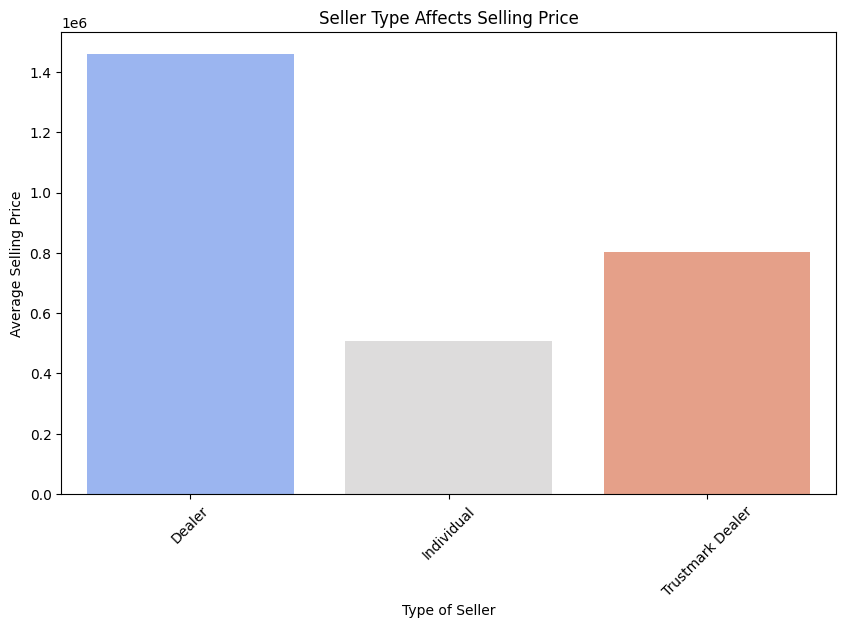

In [ ]:
#Bar chart for average selling price by seller type
selling_price_seller_types = df.groupby('seller_type')['selling_price'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=selling_price_seller_types.index, y=selling_price_seller_types.values, palette='coolwarm')
plt.xlabel("Type of Seller")
plt.ylabel("Average Selling Price")
plt.title("Seller Type Affects Selling Price")
plt.xticks(rotation=45)
plt.show()

How does the number of previous owners affect the average selling price of cars?

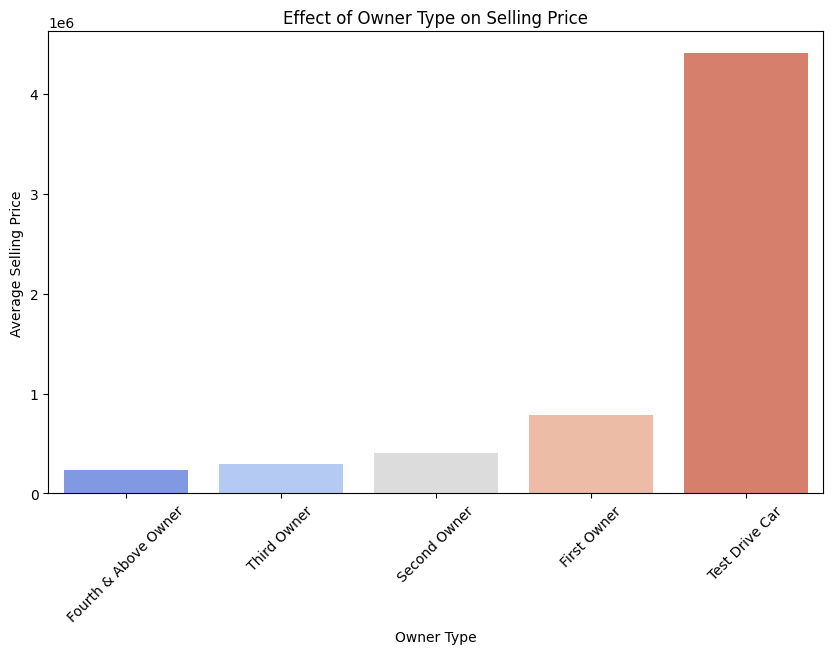

In [ ]:
#average selling price for each owner type
owner_price = df.groupby('owner')['selling_price'].mean().sort_values()

#plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=owner_price.index, y=owner_price.values, palette='coolwarm')

#Labels & Title
plt.xlabel("Owner Type")
plt.ylabel("Average Selling Price")
plt.title("Effect of Owner Type on Selling Price")
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [ ]:
df[['mileage', 'engine', 'max_power']]

,mileage,engine,max_power
0,23.4 kmpl,1248 CC,74 bhp
1,21.14 kmpl,1498 CC,103.52 bhp
2,17.7 kmpl,1497 CC,78 bhp
3,23.0 kmpl,1396 CC,90 bhp
4,16.1 kmpl,1298 CC,88.2 bhp
...,...,...,...
7901,18.5 kmpl,1197 CC,82.85 bhp
7902,16.8 kmpl,1493 CC,110 bhp
7903,19.3 kmpl,1248 CC,73.9 bhp
7904,23.57 kmpl,1396 CC,70 bhp


In [ ]:
#Removing non-numeric characters and converting to float
cols_to_clean = ['mileage', 'engine', 'max_power']
df[cols_to_clean] = df[cols_to_clean].replace(r'[^0-9.]', '', regex=True).astype(float)

In [ ]:
df[['mileage', 'engine', 'max_power']]

,mileage,engine,max_power
0,23.40,1248.0,74.00
1,21.14,1498.0,103.52
2,17.70,1497.0,78.00
3,23.00,1396.0,90.00
4,16.10,1298.0,88.20
...,...,...,...
7901,18.50,1197.0,82.85
7902,16.80,1493.0,110.00
7903,19.30,1248.0,73.90
7904,23.57,1396.0,70.00


In [ ]:
##Deleting the column 'torque' because there are many words and specifications that can be ignored.
df.drop('torque', axis = 1, inplace= True)

In [ ]:
#Chande column year to Age of production Car
df.rename(columns={'year':'age'}, inplace=True)
df['age'] = 2025 - df['age']

In [ ]:
#Data After some of Preprocessing
df.head()

,name,age,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,11,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,11,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,19,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,15,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,18,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


Let's encode the data and make it model ready

In [ ]:
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])

In [ ]:
owner_order = [['Test Drive Car', 'First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']]
oe = OrdinalEncoder(categories=owner_order)
df['owner'] = oe.fit_transform(df[['owner']])

In [ ]:
df.head()

,name,age,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,20,11,450000,145500,1,23,1248,74,5,1,0,0,1,0,1
1,26,11,370000,120000,2,21,1498,103,5,1,0,0,1,0,1
2,10,19,158000,140000,3,17,1497,78,5,0,0,1,1,0,1
3,11,15,225000,127000,1,23,1396,90,5,1,0,0,1,0,1
4,20,18,130000,120000,1,16,1298,88,5,0,0,1,1,0,1


In [ ]:
categorical_cols = ['fuel', 'seller_type', 'transmission']  # Nominal
# Check if columns exist before applying get_dummies
for col in categorical_cols:
    if col not in df.columns:
        print(f"Column '{col}' not found in DataFrame. Skipping...")
    else:
        # Apply get_dummies only if the column exists
        df = pd.get_dummies(df, columns=[col], drop_first=True)

# Converting boolean columns to 0/1
df = df.astype(int)

print(df.head())

Column 'fuel' not found in DataFrame. Skipping...
Column 'seller_type' not found in DataFrame. Skipping...
Column 'transmission' not found in DataFrame. Skipping...
   name  age  ...  seller_type_Trustmark Dealer  transmission_Manual
0    20   11  ...                             0                    1
1    26   11  ...                             0                    1
2    10   19  ...                             0                    1
3    11   15  ...                             0                    1
4    20   18  ...                             0                    1

[5 rows x 15 columns]


In [ ]:
df.head()

,name,age,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,20,11,450000,145500,1,23,1248,74,5,1,0,0,1,0,1
1,26,11,370000,120000,2,21,1498,103,5,1,0,0,1,0,1
2,10,19,158000,140000,3,17,1497,78,5,0,0,1,1,0,1
3,11,15,225000,127000,1,23,1396,90,5,1,0,0,1,0,1
4,20,18,130000,120000,1,16,1298,88,5,0,0,1,1,0,1


In [ ]:
df.sample(5)

,name,age,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
4851,28,10,1050000,70000,1,12,2494,100,7,1,0,0,1,0,1
2727,20,8,635000,40000,1,26,1248,74,5,1,0,0,1,0,1
4304,26,9,645000,11000,1,14,1598,103,5,0,0,1,0,0,0
7696,27,15,169000,100000,2,15,1368,90,5,0,0,1,1,0,1
6727,20,26,70000,65000,4,15,1298,85,5,0,0,1,1,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df[df.columns])  #Scale all columns

print(df.head())

       name       age  ...  seller_type_Trustmark Dealer  transmission_Manual
0  0.318278 -0.004158  ...                     -0.175412             0.389408
1  1.166997 -0.004158  ...                     -0.175412             0.389408
2 -1.096253  2.066530  ...                     -0.175412             0.389408
3 -0.954799  1.031186  ...                     -0.175412             0.389408
4  0.318278  1.807694  ...                     -0.175412             0.389408

[5 rows x 15 columns]


Assign feature and target variables

In [ ]:
X = df.drop('selling_price', axis=1)
Y = df['selling_price']

In [ ]:
#Splitting Data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state = 44, shuffle = True)

In [ ]:
print(f'Shape of X_Train {X_train.shape}')
print(f'Shape of X_Test {X_test.shape}')
print(f'Shape of Y_Train {Y_train.shape}')
print(f'Shape of Y_Test {Y_test.shape}')

Shape of X_Train (5929, 14)
Shape of X_Test (1977, 14)
Shape of Y_Train (5929,)
Shape of Y_Test (1977,)


In [ ]:
#for storing the results of models

df_results = pd.DataFrame(columns=["Model", "Testing Accuracy(%)"])

OG Linear Regression

In [ ]:
lr = LinearRegression()
scores = cross_val_score(lr, X, Y, cv=10)

lr.fit(X_train, Y_train)

print("Cross-Validation Score:", scores.mean() * 100)
print("Training Accuracy:", lr.score(X_train, Y_train) * 100)
print("Testing Accuracy:", lr.score(X_test, Y_test) * 100)
print("R2 Score:", r2_score(Y_test, lr.predict(X_test)) * 100)

#Storing results in DataFrame
df_results.loc[len(df_results)] = ["Linear Regression", lr.score(X_test, Y_test) * 100]

Cross-Validation Score: 66.14491915199604
Training Accuracy: 67.73261727805418
Testing Accuracy: 69.0175767931842
R2 Score: 69.0175767931842


Random Forest Model(Bagging)

In [ ]:
#Initializing the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10)

#Training model
rf_model.fit(X_train,  Y_train)

#Training & Testing Accuracy
print("Training Accuracy:", rf_model.score(X_train, Y_train) * 100)
print("Testing Accuracy:", rf_model.score(X_test, Y_test) * 100)

# R² Score
print("R² Score:", r2_score(Y_test, rf_model.predict(X_test)) * 100)

#Storing results in DataFrame
df_results.loc[len(df_results)] = ["Random Forest", rf_model.score(X_test, Y_test) * 100]

Training Accuracy: 98.81351414058716
Testing Accuracy: 97.01813398275422
R² Score: 97.01813398275422


XGboosting Model(Boosting)

In [ ]:
# Initializing the model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)

# Training the model
xgb_model.fit(X_train, Y_train)

# Training & Testing Accuracy
print("Training Accuracy:", xgb_model.score(X_train, Y_train) * 100)
print("Testing Accuracy:", xgb_model.score(X_test, Y_test) * 100)

# R² Score
print("R² Score:", r2_score(Y_test, xgb_model.predict(X_test)) * 100)

df_results.loc[len(df_results)] = ["XGBoost", xgb_model.score(X_test, Y_test) * 100]

Training Accuracy: 96.97466073664275
Testing Accuracy: 95.8521183971291
R² Score: 95.8521183971291


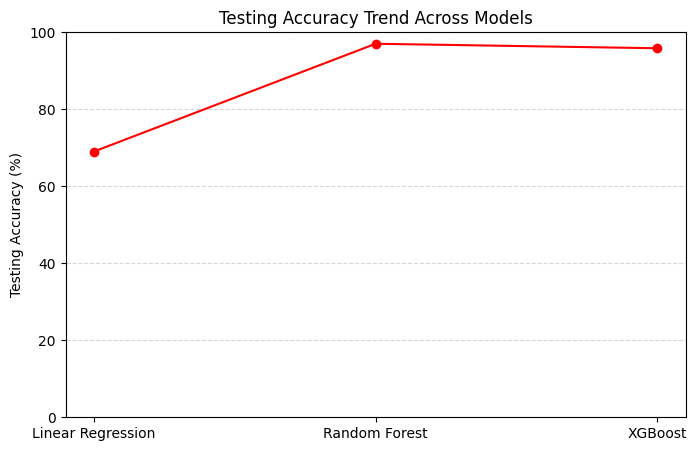

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_results["Model"], df_results["Testing Accuracy(%)"], marker='o', linestyle='-', color='red') #Fixed the column name
plt.title("Testing Accuracy Trend Across Models")
plt.ylabel("Testing Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle="--", alpha=0.5)  # alpha → Transparency of the line
plt.show()

Hyperparameter Tuning (Improving Model Performance)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Defining parameter grid
param_grid = {
    'n_estimators': [100, 200 , 300],
    'max_depth': [5, 10, 15],
}

# Grid Search
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)
grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 15, 'n_estimators': 100}
Best Score: 0.959499792302886


Feature Importance Analysis(Understanding what matter)

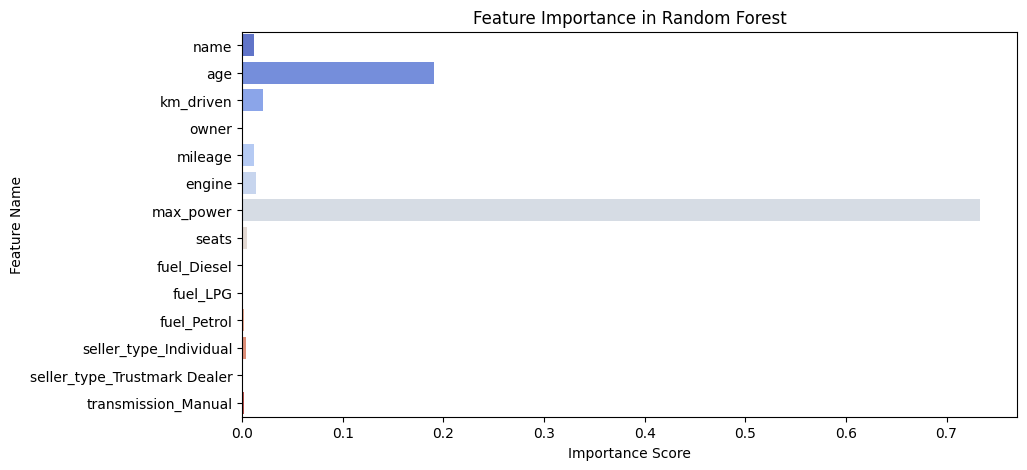

In [ ]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feature_names, palette="coolwarm")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Random Forest")
plt.show()